# Geodemographic Clustering Case Study

Demonstrates that learned embeddings (100D) can be used for geodemographic classification.
Creates 8-cluster classifications from AE and PCA embeddings, evaluates cluster quality.

In [4]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, 
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    v_measure_score
)

import warnings
warnings.filterwarnings('ignore')

## Configuration

In [5]:
# Parameters
target_dim = 100
n_clusters = 8  # Match OAC supergroups
random_seed = 20210321

# Paths
data_path = "../AE_outputs/engcensus_all/"
working_dir = data_path + "250epoch_scan_lin"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geo_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
oac_path = "../data/OAC/OAC_assignment.csv"

# Output
output_dir = "./plots/geodemo_clustering/"
os.makedirs(output_dir, exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings")
print(f"Random seed: {random_seed}")

Creating 8 clusters from 100D embeddings
Random seed: 20210321


## Load Data

In [6]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
pca_latent_df = pd.DataFrame(pca_embeddings, index=df_census.index)
print(f"PCA embeddings: {pca_latent_df.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings
ae_latent_path = f"{working_dir}/census_geodemo__bottleneck_{target_dim}_v1__latent.csv"
print(f"\nLoading AE embeddings from: {ae_latent_path}")
if os.path.exists(ae_latent_path):
    ae_latent_df = pd.read_csv(ae_latent_path, index_col="OA")
    ae_latent_df = ae_latent_df.reindex(df_census.index)
    print(f"AE embeddings: {ae_latent_df.shape}")
else:
    raise FileNotFoundError(f"AE latent file not found at {ae_latent_path}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")

Loading census data...
Census data: (188880, 408)

Computing PCA 100D embeddings...
PCA embeddings: (188880, 100)
Explained variance: 0.984

Loading AE embeddings from: ../AE_outputs/engcensus_all/250epoch_scan_lin/census_geodemo__bottleneck_100_v1__latent.csv
AE embeddings: (188880, 100)

Loading OAC classifications...
OAC: (188880, 1)
OAC Supergroups: 8 unique groups


Creating clustergrams for PCA and AE embeddings...
Testing cluster counts: k=1 to k=16

Generating PCA clustergram...
K=1 skipped. Mean computed from data directly.
K=2 fitted in 2.806 seconds.
K=3 fitted in 2.796 seconds.
K=4 fitted in 3.566 seconds.
K=5 fitted in 4.145 seconds.
K=6 fitted in 5.082 seconds.
K=7 fitted in 6.379 seconds.
K=8 fitted in 5.455 seconds.
K=9 fitted in 8.111 seconds.
Generating AE clustergram...
K=1 skipped. Mean computed from data directly.
K=2 fitted in 2.557 seconds.
K=3 fitted in 2.712 seconds.
K=4 fitted in 4.350 seconds.
K=5 fitted in 5.461 seconds.
K=6 fitted in 5.063 seconds.
K=7 fitted in 7.024 seconds.
K=8 fitted in 9.236 seconds.
K=9 fitted in 9.245 seconds.


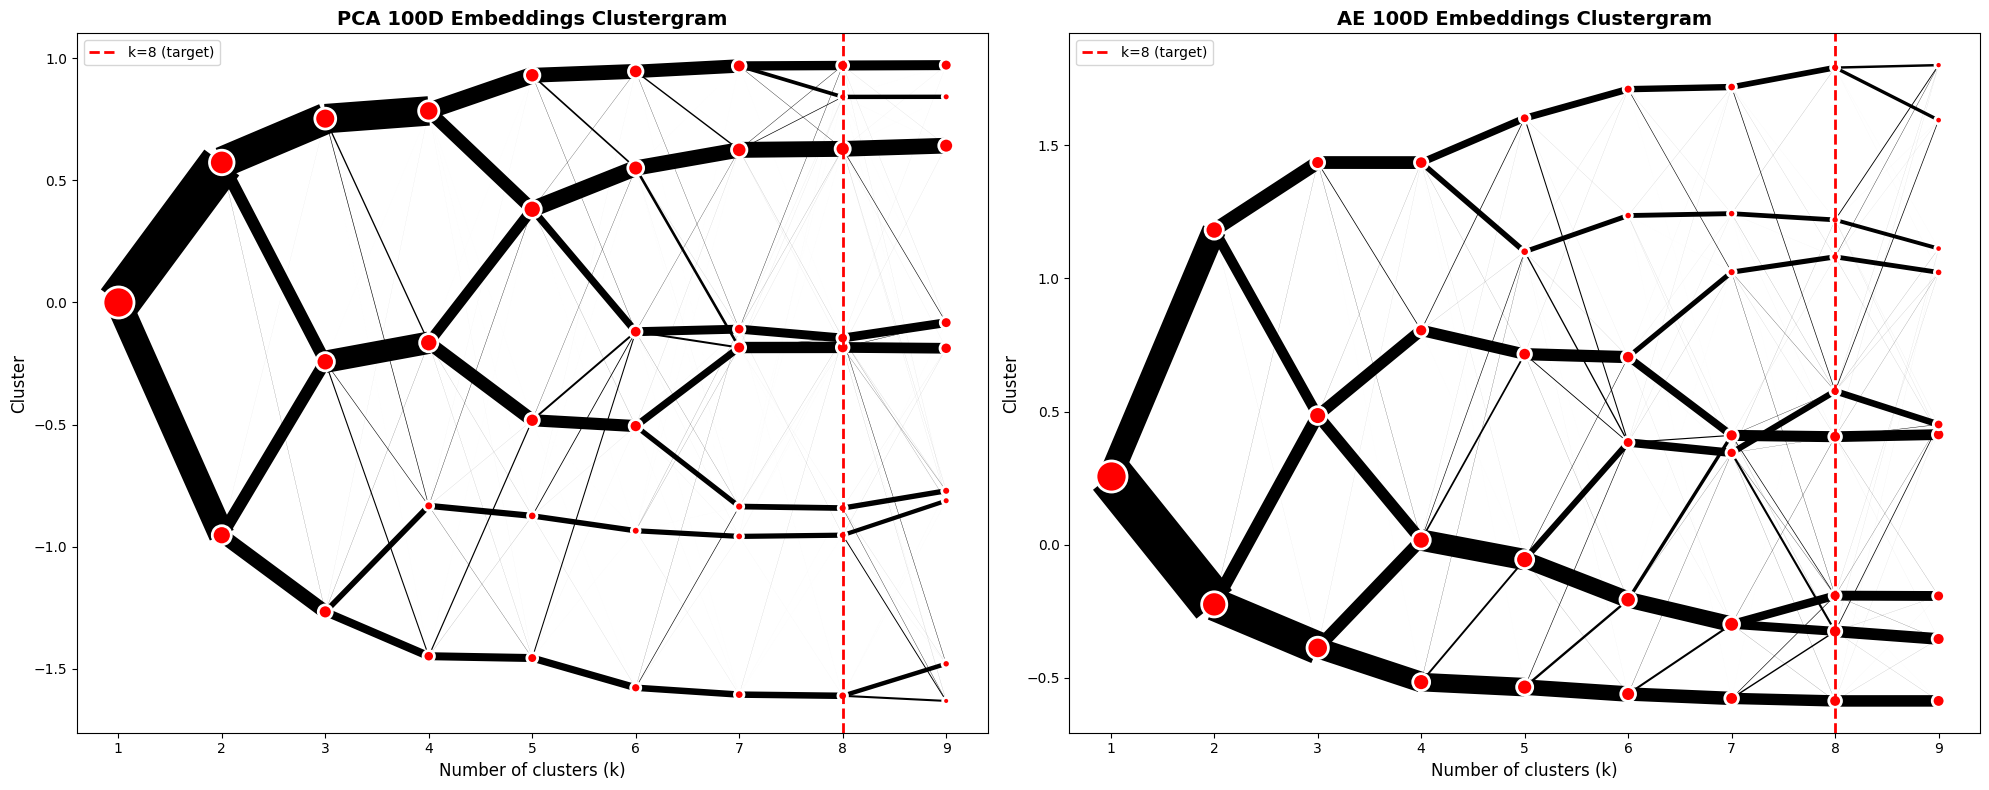


✓ Clustergrams saved to ./plots/geodemo_clustering//clustergram_comparison_100d.png


In [9]:
# Make a clustergram for PCA and AE embeddings
import clustergram



# Create clustergram for PCA embeddings
print("\nGenerating PCA clustergram...")
cgram_pca = clustergram.Clustergram(range(1,10), n_init=10, random_state=random_seed)
cgram_pca.fit(pca_latent_df)

# Create clustergram for AE embeddings  
print("Generating AE clustergram...")
cgram_ae = clustergram.Clustergram(range(1,10), n_init=10, random_state=random_seed)
cgram_ae.fit(ae_latent_df)

# Plot both clustergrams side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA clustergram
cgram_pca.plot(ax=axes[0], figsize=None)
axes[0].set_title(f'PCA {target_dim}D Embeddings Clustergram', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)', fontsize=12)
axes[0].set_ylabel('Cluster', fontsize=12)
axes[0].axvline(x=n_clusters, color='red', linestyle='--', linewidth=2, label=f'k={n_clusters} (target)')
axes[0].legend()

# AE clustergram
cgram_ae.plot(ax=axes[1], figsize=None)
axes[1].set_title(f'AE {target_dim}D Embeddings Clustergram', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)', fontsize=12)
axes[1].set_ylabel('Cluster', fontsize=12)
axes[1].axvline(x=n_clusters, color='red', linestyle='--', linewidth=2, label=f'k={n_clusters} (target)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/clustergram_comparison_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Clustergrams saved to {output_dir}/clustergram_comparison_{target_dim}d.png")

## K-Means Clustering

In [10]:
print(f"Performing K-Means clustering (k={n_clusters})...\n")

# PCA clustering
print("PCA embeddings...")
kmeans_pca = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init=100, max_iter=1000)
pca_clusters = kmeans_pca.fit_predict(pca_latent_df)
print(f"  Inertia: {kmeans_pca.inertia_:.2f}")
print(f"  Iterations: {kmeans_pca.n_iter_}")

# AE clustering
print("\nAE embeddings...")
kmeans_ae = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init=100, max_iter=1000)
ae_clusters = kmeans_ae.fit_predict(ae_latent_df)
print(f"  Inertia: {kmeans_ae.inertia_:.2f}")
print(f"  Iterations: {kmeans_ae.n_iter_}")

# Create results dataframe
clusters_df = pd.DataFrame({
    'pca_cluster': pca_clusters,
    'ae_cluster': ae_clusters,
    'oac_supergroup': oac['Supergroup8'].values
}, index=df_census.index)

print("\nCluster distributions:")
print("\nPCA clusters:")
print(clusters_df['pca_cluster'].value_counts().sort_index())
print("\nAE clusters:")
print(clusters_df['ae_cluster'].value_counts().sort_index())

Performing K-Means clustering (k=8)...

PCA embeddings...
  Inertia: 219352.04
  Iterations: 35

AE embeddings...
  Inertia: 172323.10
  Iterations: 29

Cluster distributions:

PCA clusters:
pca_cluster
0    27647
1    17725
2    44570
3    26305
4    14335
5    30640
6    15561
7    12097
Name: count, dtype: int64

AE clusters:
ae_cluster
0    15795
1    34135
2    20401
3    31060
4    13131
5    28254
6    14201
7    31903
Name: count, dtype: int64


## Cluster Quality Metrics

Evaluating cluster quality using multiple metrics:
- **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters (-1 to 1, higher is better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower is better)
- **Calinski-Harabasz Score**: Ratio of between-cluster to within-cluster variance (higher is better)

In [5]:
print("Computing cluster quality metrics...\n")

# WSSC (Within-cluster Sum of Squares) - already computed by KMeans
print("Within-cluster Sum of Squares (WSSC / Inertia - lower is better):")
wssc_pca = kmeans_pca.inertia_
wssc_ae = kmeans_ae.inertia_
print(f"  PCA:  {wssc_pca:.2f}")
print(f"  AE:   {wssc_ae:.2f}")
print(f"  Difference: {wssc_ae - wssc_pca:+.2f}")

# For silhouette scores, use a sample to speed up computation
# (Silhouette is O(n²) in memory and computation)
sample_size = 10000  # Use 10k samples instead of 188k for speed
print(f"\nUsing {sample_size:,} sample for silhouette computation (full dataset: {len(pca_latent_df):,})")

# Create stratified sample (proportional from each cluster)
np.random.seed(random_seed)
pca_sample_idx = []
ae_sample_idx = []

for i in range(n_clusters):
    # PCA samples
    pca_cluster_idx = np.where(pca_clusters == i)[0]
    pca_n_sample = max(int(len(pca_cluster_idx) * sample_size / len(pca_clusters)), 10)
    pca_sample_idx.extend(np.random.choice(pca_cluster_idx, size=min(pca_n_sample, len(pca_cluster_idx)), replace=False))
    
    # AE samples
    ae_cluster_idx = np.where(ae_clusters == i)[0]
    ae_n_sample = max(int(len(ae_cluster_idx) * sample_size / len(ae_clusters)), 10)
    ae_sample_idx.extend(np.random.choice(ae_cluster_idx, size=min(ae_n_sample, len(ae_cluster_idx)), replace=False))

pca_sample_idx = np.array(pca_sample_idx)
ae_sample_idx = np.array(ae_sample_idx)

# Silhouette scores (on sample)
print("\nSilhouette Scores (sampled):")
silhouette_pca = silhouette_score(pca_latent_df.iloc[pca_sample_idx], pca_clusters[pca_sample_idx])
silhouette_ae = silhouette_score(ae_latent_df.iloc[ae_sample_idx], ae_clusters[ae_sample_idx])
print(f"  PCA:  {silhouette_pca:.4f}")
print(f"  AE:   {silhouette_ae:.4f}")
print(f"  Difference: {silhouette_ae - silhouette_pca:+.4f}")

# Davies-Bouldin Index (lower is better) - FAST, use full data
print("\nDavies-Bouldin Index (lower is better):")
db_pca = davies_bouldin_score(pca_latent_df, pca_clusters)
db_ae = davies_bouldin_score(ae_latent_df, ae_clusters)
print(f"  PCA:  {db_pca:.4f}")
print(f"  AE:   {db_ae:.4f}")
print(f"  Difference: {db_ae - db_pca:+.4f}")

# Calinski-Harabasz Score (higher is better) - FAST, use full data
print("\nCalinski-Harabasz Score (higher is better):")
ch_pca = calinski_harabasz_score(pca_latent_df, pca_clusters)
ch_ae = calinski_harabasz_score(ae_latent_df, ae_clusters)
print(f"  PCA:  {ch_pca:.2f}")
print(f"  AE:   {ch_ae:.2f}")
print(f"  Difference: {ch_ae - ch_pca:+.2f}")

# Per-cluster silhouette scores (on sample)
print("\nPer-cluster silhouette scores (sampled):")
silhouette_pca_samples = silhouette_samples(pca_latent_df.iloc[pca_sample_idx], pca_clusters[pca_sample_idx])
silhouette_ae_samples = silhouette_samples(ae_latent_df.iloc[ae_sample_idx], ae_clusters[ae_sample_idx])

print("\nPCA:")
for i in range(n_clusters):
    cluster_silhouette = silhouette_pca_samples[pca_clusters[pca_sample_idx] == i].mean()
    cluster_size = (pca_clusters == i).sum()
    print(f"  Cluster {i}: {cluster_silhouette:.4f} (n={cluster_size:,})")

print("\nAE:")
for i in range(n_clusters):
    cluster_silhouette = silhouette_ae_samples[ae_clusters[ae_sample_idx] == i].mean()
    cluster_size = (ae_clusters == i).sum()
    print(f"  Cluster {i}: {cluster_silhouette:.4f} (n={cluster_size:,})")

# Store for comparison
quality_metrics = pd.DataFrame({
    'Metric': ['WSSC/Inertia', 'Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'PCA': [wssc_pca, silhouette_pca, db_pca, ch_pca],
    'AE': [wssc_ae, silhouette_ae, db_ae, ch_ae],
    'Better': ['Lower', 'Higher', 'Lower', 'Higher']
})
quality_metrics['Winner'] = quality_metrics.apply(
    lambda row: 'AE' if (row['Better'] == 'Higher' and row['AE'] > row['PCA']) or 
                        (row['Better'] == 'Lower' and row['AE'] < row['PCA']) else 'PCA',
    axis=1
)

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(quality_metrics.to_string(index=False))

# Save results
data_dir = f"{output_dir}/data/"
os.makedirs(data_dir, exist_ok=True)
quality_metrics.to_csv(f"{data_dir}/quality_metrics_{target_dim}d.csv", index=False)

# Save sample indices and silhouette samples for plotting
np.savez(f"{data_dir}/silhouette_data_{target_dim}d.npz",
         pca_sample_idx=pca_sample_idx,
         ae_sample_idx=ae_sample_idx,
         silhouette_pca_samples=silhouette_pca_samples,
         silhouette_ae_samples=silhouette_ae_samples,
         pca_clusters_sampled=pca_clusters[pca_sample_idx],
         ae_clusters_sampled=ae_clusters[ae_sample_idx])

print(f"\n✓ Saved quality metrics and silhouette data to {data_dir}")

Computing cluster quality metrics...

Within-cluster Sum of Squares (WSSC / Inertia - lower is better):
  PCA:  219352.04
  AE:   172323.10
  Difference: -47028.95

Using 10,000 sample for silhouette computation (full dataset: 188,880)

Silhouette Scores (sampled):
  PCA:  0.1247
  AE:   0.1099
  Difference: -0.0148

Davies-Bouldin Index (lower is better):
  PCA:  1.8932
  AE:   2.0210
  Difference: +0.1278

Calinski-Harabasz Score (higher is better):
  PCA:  26125.44
  AE:   26030.64
  Difference: -94.80

Per-cluster silhouette scores (sampled):

PCA:
  Cluster 0: 0.1527 (n=27,647)
  Cluster 1: 0.1109 (n=17,725)
  Cluster 2: 0.1430 (n=44,570)
  Cluster 3: 0.0441 (n=26,305)
  Cluster 4: 0.1359 (n=14,335)
  Cluster 5: 0.1231 (n=30,640)
  Cluster 6: 0.0731 (n=15,561)
  Cluster 7: 0.2459 (n=12,097)

AE:
  Cluster 0: 0.1011 (n=15,795)
  Cluster 1: 0.1028 (n=34,135)
  Cluster 2: 0.0615 (n=20,401)
  Cluster 3: 0.1121 (n=31,060)
  Cluster 4: 0.1155 (n=13,131)
  Cluster 5: 0.0929 (n=28,254)
  

## Comparison to OAC

How well do the learned embeddings align with the official OAC classification?

In [6]:
print("Comparing to OAC Supergroups...\n")

# Adjusted Rand Index (measures clustering agreement)
print("Adjusted Rand Index (ARI):")
ari_pca = adjusted_rand_score(oac['Supergroup8'].values, pca_clusters)
ari_ae = adjusted_rand_score(oac['Supergroup8'].values, ae_clusters)
print(f"  PCA vs OAC:  {ari_pca:.4f}")
print(f"  AE vs OAC:   {ari_ae:.4f}")
print(f"  Difference:  {ari_ae - ari_pca:+.4f}")

# V-measure (measures clustering quality against ground truth)
print("\nV-Measure Score:")
v_pca = v_measure_score(oac['Supergroup8'].values, pca_clusters)
v_ae = v_measure_score(oac['Supergroup8'].values, ae_clusters)
print(f"  PCA vs OAC:  {v_pca:.4f}")
print(f"  AE vs OAC:   {v_ae:.4f}")
print(f"  Difference:  {v_ae - v_pca:+.4f}")

print("\nInterpretation:")
print("- ARI close to 0: Random labeling")
print("- ARI close to 1: Perfect agreement")
print("- Low ARI expected: Different methods capture different aspects")

Comparing to OAC Supergroups...

Adjusted Rand Index (ARI):
  PCA vs OAC:  0.2814
  AE vs OAC:   0.2766
  Difference:  -0.0048

V-Measure Score:
  PCA vs OAC:  0.4374
  AE vs OAC:   0.4318
  Difference:  -0.0056

Interpretation:
- ARI close to 0: Random labeling
- ARI close to 1: Perfect agreement
- Low ARI expected: Different methods capture different aspects


Computing cluster-to-OAC overlap matrices...

PCA: 188,880 OAs with valid OAC labels
AE: 188,880 OAs with valid OAC labels

PCA clusters → OAC distribution (% of cluster):
       Cluster_0  Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5  \
OAC_1       47.5        0.0       26.9        0.0        0.0        0.0   
OAC_2       21.4        0.0       49.3       17.0        0.0        4.3   
OAC_3        0.0       76.3        0.0        4.2        1.6        0.0   
OAC_4        0.0       18.7        0.2        8.4       90.9        6.9   
OAC_5       30.8        0.3       12.1       18.0        6.4        0.2   
OAC_6        0.3        4.6        3.6       50.6        1.0       33.9   
OAC_7        0.0        0.0        7.7        1.6        0.0       54.0   
OAC_8        0.0        0.1        0.1        0.1        0.0        0.7   

       Cluster_6  Cluster_7  
OAC_1        0.8       46.2  
OAC_2        7.6       51.6  
OAC_3        7.7        0.0  
OAC_4        6.7        0.0  
OA

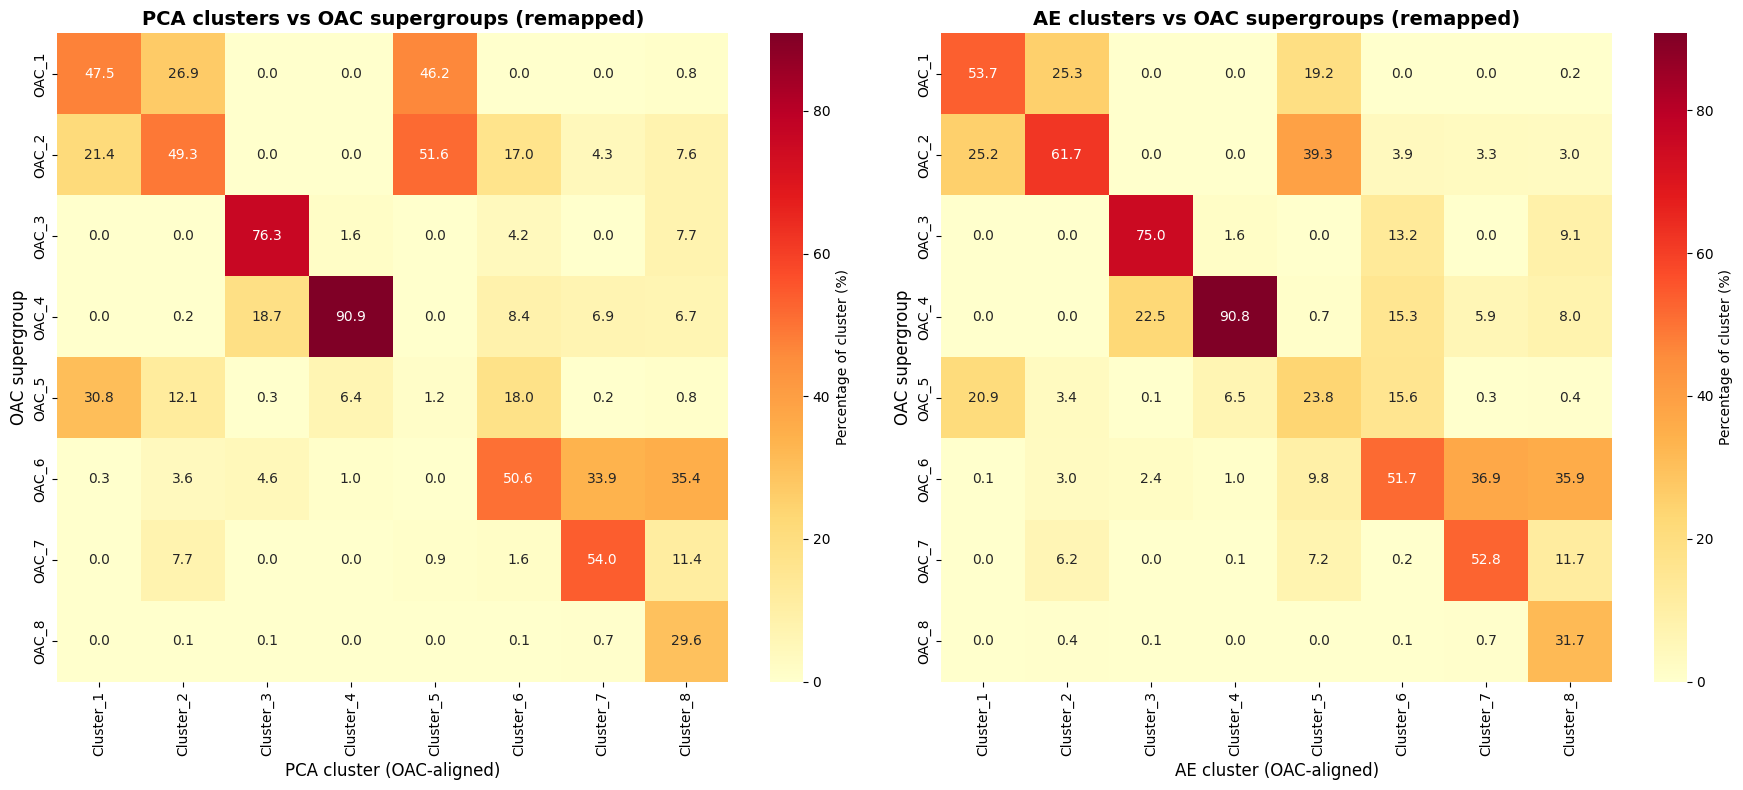


✓ Saved overlap matrices and remapping tables to ./plots/geodemo_clustering/
⚠️  All subsequent cells will use OAC-aligned cluster IDs!


In [15]:
print("Computing cluster-to-OAC overlap matrices...\n")

def cluster_oac_overlap(cluster_labels, oac_labels, method_name, cluster_axis):
    """Return count and percentage matrices with clusters on the X-axis."""
    valid_mask = ~pd.isna(oac_labels)
    oac_valid = oac_labels[valid_mask]
    clusters_valid = cluster_labels[valid_mask]

    print(f"{method_name}: {valid_mask.sum():,} OAs with valid OAC labels")

    oac_ids = list(range(1, n_clusters + 1))
    counts = pd.crosstab(oac_valid, clusters_valid)
    counts = counts.reindex(index=oac_ids, columns=cluster_axis, fill_value=0)
    counts.index = [f'OAC_{oid}' for oid in counts.index]
    counts.columns = [f'Cluster_{cid}' for cid in counts.columns]

    percentages = counts.divide(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100
    percentages = percentages.fillna(0)

    return counts, percentages

original_cluster_axis = list(range(n_clusters))
pca_counts, pca_percent = cluster_oac_overlap(pca_clusters, oac['Supergroup8'].values, 'PCA', original_cluster_axis)
ae_counts, ae_percent = cluster_oac_overlap(ae_clusters, oac['Supergroup8'].values, 'AE', original_cluster_axis)

print("\nPCA clusters → OAC distribution (% of cluster):")
print(pca_percent.round(1))
print("\nAE clusters → OAC distribution (% of cluster):")
print(ae_percent.round(1))

def greedy_one_to_one_mapping(counts_df):
    """Greedily assign each cluster to a unique OAC by highest overlap."""
    flattened = counts_df.stack().sort_values(ascending=False)
    cluster_mapping = {}
    used_oac = set()
    for (oac_label, cluster_label), value in flattened.items():
        cluster_id = int(cluster_label.split('_')[1])
        oac_id = int(oac_label.split('_')[1])
        if cluster_id not in cluster_mapping and oac_id not in used_oac:
            cluster_mapping[cluster_id] = oac_id
            used_oac.add(oac_id)
        if len(cluster_mapping) == counts_df.shape[1]:
            break

    remaining_clusters = sorted(set(range(counts_df.shape[1])) - set(cluster_mapping.keys()))
    remaining_oac = sorted(set(range(1, counts_df.shape[0] + 1)) - used_oac)
    for cluster_id, oac_id in zip(remaining_clusters, remaining_oac):
        cluster_mapping[cluster_id] = oac_id

    return cluster_mapping

pca_mapping = greedy_one_to_one_mapping(pca_counts)
ae_mapping = greedy_one_to_one_mapping(ae_counts)

print("\n" + "="*80)
print("Greedy one-to-one remapping (PCA clusters → OAC supergroups)")
print("="*80)
for cluster_id in sorted(pca_mapping.keys()):
    oac_id = pca_mapping[cluster_id]
    overlap = int(pca_counts.loc[f'OAC_{oac_id}', f'Cluster_{cluster_id}'])
    total = int(pca_counts[f'Cluster_{cluster_id}'].sum())
    pct = (overlap / total * 100) if total else 0.0
    print(f"  Cluster {cluster_id} → OAC {oac_id}: {overlap}/{total} OAs ({pct:.1f}%)")

print("\n" + "="*80)
print("Greedy one-to-one remapping (AE clusters → OAC supergroups)")
print("="*80)
for cluster_id in sorted(ae_mapping.keys()):
    oac_id = ae_mapping[cluster_id]
    overlap = int(ae_counts.loc[f'OAC_{oac_id}', f'Cluster_{cluster_id}'])
    total = int(ae_counts[f'Cluster_{cluster_id}'].sum())
    pct = (overlap / total * 100) if total else 0.0
    print(f"  Cluster {cluster_id} → OAC {oac_id}: {overlap}/{total} OAs ({pct:.1f}%)")

# Apply remapping to cluster assignments
pca_clusters_remapped = np.array([pca_mapping[c] for c in pca_clusters])
ae_clusters_remapped = np.array([ae_mapping[c] for c in ae_clusters])

# Update global state
clusters_df['pca_cluster'] = pca_clusters_remapped
clusters_df['ae_cluster'] = ae_clusters_remapped

if 'gdf' in locals():
    gdf['pca_cluster'] = pca_clusters_remapped
    gdf['ae_cluster'] = ae_clusters_remapped

pca_clusters = pca_clusters_remapped
ae_clusters = ae_clusters_remapped

# Recompute overlap matrices after remapping (clusters now 1..n_clusters)
remapped_cluster_axis = list(range(1, n_clusters + 1))
pca_counts_remap, pca_percent_remap = cluster_oac_overlap(pca_clusters, oac['Supergroup8'].values, 'PCA (remapped)', remapped_cluster_axis)
ae_counts_remap, ae_percent_remap = cluster_oac_overlap(ae_clusters, oac['Supergroup8'].values, 'AE (remapped)', remapped_cluster_axis)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(pca_percent_remap, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Percentage of cluster (%)'})
axes[0].set_title('PCA clusters vs OAC supergroups (remapped)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PCA cluster (OAC-aligned)', fontsize=12)
axes[0].set_ylabel('OAC supergroup', fontsize=12)

sns.heatmap(ae_percent_remap, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': 'Percentage of cluster (%)'})
axes[1].set_title('AE clusters vs OAC supergroups (remapped)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AE cluster (OAC-aligned)', fontsize=12)
axes[1].set_ylabel('OAC supergroup', fontsize=12)

plt.tight_layout()
plt.savefig(f"{output_dir}/cluster_oac_overlap_remapped_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

# Save mapping tables
pca_mapping_df = pd.DataFrame([
    {
        'original_cluster': cluster_id,
        'remapped_cluster': pca_mapping[cluster_id],
        'overlap_count': int(pca_counts.loc[f'OAC_{pca_mapping[cluster_id]}', f'Cluster_{cluster_id}']),
        'cluster_total': int(pca_counts[f'Cluster_{cluster_id}'].sum()),
        'overlap_pct': float(pca_percent.loc[f'OAC_{pca_mapping[cluster_id]}', f'Cluster_{cluster_id}'])
    }
    for cluster_id in sorted(pca_mapping.keys())
 ])
pca_mapping_df.to_csv(f"{output_dir}/pca_cluster_remapping_{target_dim}d.csv", index=False)

ae_mapping_df = pd.DataFrame([
    {
        'original_cluster': cluster_id,
        'remapped_cluster': ae_mapping[cluster_id],
        'overlap_count': int(ae_counts.loc[f'OAC_{ae_mapping[cluster_id]}', f'Cluster_{cluster_id}']),
        'cluster_total': int(ae_counts[f'Cluster_{cluster_id}'].sum()),
        'overlap_pct': float(ae_percent.loc[f'OAC_{ae_mapping[cluster_id]}', f'Cluster_{cluster_id}'])
    }
    for cluster_id in sorted(ae_mapping.keys())
 ])
ae_mapping_df.to_csv(f"{output_dir}/ae_cluster_remapping_{target_dim}d.csv", index=False)

# Save count/percentage matrices
pca_counts.to_csv(f"{output_dir}/pca_cluster_oac_overlap_counts_{target_dim}d.csv")
ae_counts.to_csv(f"{output_dir}/ae_cluster_oac_overlap_counts_{target_dim}d.csv")
pca_percent.to_csv(f"{output_dir}/pca_cluster_oac_overlap_percent_{target_dim}d.csv")
ae_percent.to_csv(f"{output_dir}/ae_cluster_oac_overlap_percent_{target_dim}d.csv")
pca_counts_remap.to_csv(f"{output_dir}/pca_cluster_oac_overlap_counts_remapped_{target_dim}d.csv")
ae_counts_remap.to_csv(f"{output_dir}/ae_cluster_oac_overlap_counts_remapped_{target_dim}d.csv")
pca_percent_remap.to_csv(f"{output_dir}/pca_cluster_oac_overlap_percent_remapped_{target_dim}d.csv")
ae_percent_remap.to_csv(f"{output_dir}/ae_cluster_oac_overlap_percent_remapped_{target_dim}d.csv")

print(f"\n✓ Saved overlap matrices and remapping tables to {output_dir}")
print("⚠️  All subsequent cells will use OAC-aligned cluster IDs!")

## Cluster Profiling

What are the demographic characteristics of each cluster?

In [10]:
print("Profiling clusters using census variables...\n")

# Compute mean characteristics for each cluster
def profile_clusters(cluster_labels, method_name):
    profiles = []
    
    for cluster_id in range(n_clusters):
        mask = cluster_labels == cluster_id
        cluster_data = df_census[mask]
        
        # Mean values
        cluster_mean = cluster_data.mean()
        
        # Deviation from national mean
        national_mean = df_census.mean()
        deviation = ((cluster_mean - national_mean) / national_mean * 100)
        
        # Top 5 most distinctive variables (highest positive deviation)
        top_vars = deviation.nlargest(5)
        
        profiles.append({
            'cluster': cluster_id,
            'size': mask.sum(),
            'pct': mask.sum() / len(cluster_labels) * 100,
            'top_vars': list(top_vars.index),
            'top_deviations': list(top_vars.values)
        })
    
    profile_df = pd.DataFrame(profiles)
    
    print(f"{method_name} Cluster Profiles:")
    print("="*80)
    for _, row in profile_df.iterrows():
        print(f"\nCluster {row['cluster']}: {row['size']:,} OAs ({row['pct']:.1f}%)")
        print("  Top distinctive variables:")
        for var, dev in zip(row['top_vars'], row['top_deviations']):
            print(f"    {var}: {dev:+.1f}% vs national mean")
    
    return profile_df

pca_profiles = profile_clusters(pca_clusters, "PCA")
print("\n" + "="*80 + "\n")
ae_profiles = profile_clusters(ae_clusters, "AE")

# Save profiles
pca_profiles.to_csv(f"{output_dir}/pca_cluster_profiles_{target_dim}d.csv", index=False)
ae_profiles.to_csv(f"{output_dir}/ae_cluster_profiles_{target_dim}d.csv", index=False)
print(f"\n✓ Saved profiles to {output_dir}")

Profiling clusters using census variables...

PCA Cluster Profiles:

Cluster 0: 27,647 OAs (14.6%)
  Top distinctive variables:
    ts0510008: +185.6% vs national mean
    ts0510009: +184.0% vs national mean
    ts0440002: +171.8% vs national mean
    ts0510007: +154.3% vs national mean
    ts0510010: +143.9% vs national mean

Cluster 1: 17,725 OAs (9.4%)
  Top distinctive variables:
    ts0050028: +457.8% vs national mean
    ts0460010: +457.0% vs national mean
    ts0510002: +416.1% vs national mean
    ts0050025: +405.0% vs national mean
    ts0050031: +386.5% vs national mean

Cluster 2: 44,570 OAs (23.6%)
  Top distinctive variables:
    ts0440003: +64.1% vs national mean
    ts0030006: +48.4% vs national mean
    ts0540003: +41.1% vs national mean
    ts007a0017: +39.1% vs national mean
    ts007a0018: +39.1% vs national mean

Cluster 3: 26,305 OAs (13.9%)
  Top distinctive variables:
    ts0190003: +88.7% vs national mean
    ts0440006: +76.5% vs national mean
    ts0540005: +74

## Visualizations

✓ Loaded silhouette data from ./plots/geodemo_clustering//data/


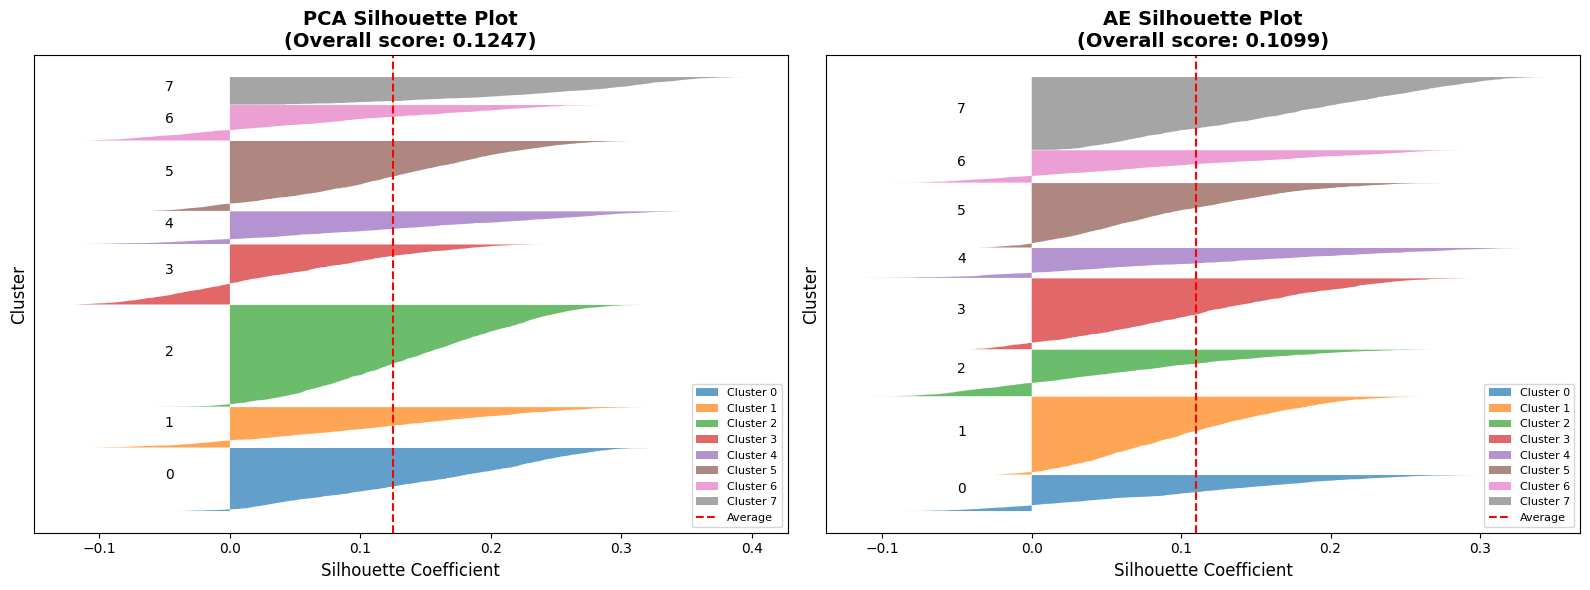

In [17]:
# Load silhouette data if not in memory
try:
    # Check if variables exist
    pca_clusters_sampled
    silhouette_pca_samples
except NameError:
    data_dir = f"{output_dir}/data/"
    silhouette_data = np.load(f"{data_dir}/silhouette_data_{target_dim}d.npz")
    pca_sample_idx = silhouette_data['pca_sample_idx']
    ae_sample_idx = silhouette_data['ae_sample_idx']
    silhouette_pca_samples = silhouette_data['silhouette_pca_samples']
    silhouette_ae_samples = silhouette_data['silhouette_ae_samples']
    pca_clusters_sampled = silhouette_data['pca_clusters_sampled']
    ae_clusters_sampled = silhouette_data['ae_clusters_sampled']
    print(f"✓ Loaded silhouette data from {data_dir}")

# Silhouette plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (method, clusters_sampled, samples, ax) in enumerate([
    ('PCA', pca_clusters_sampled, silhouette_pca_samples, axes[0]),
    ('AE', ae_clusters_sampled, silhouette_ae_samples, axes[1])
]):
    y_lower = 10
    for i in range(n_clusters):
        cluster_silhouette_values = samples[clusters_sampled == i]
        cluster_silhouette_values.sort()
        
        size_cluster_i = cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                         alpha=0.7, label=f'Cluster {i}')
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    
    overall_score = samples.mean()
    ax.set_title(f'{method} Silhouette Plot\n(Overall score: {overall_score:.4f})', fontsize=14, fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient', fontsize=12)
    ax.set_ylabel('Cluster', fontsize=12)
    ax.axvline(x=overall_score, color="red", linestyle="--", label='Average')
    ax.set_yticks([])
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig(f"{output_dir}/silhouette_comparison_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

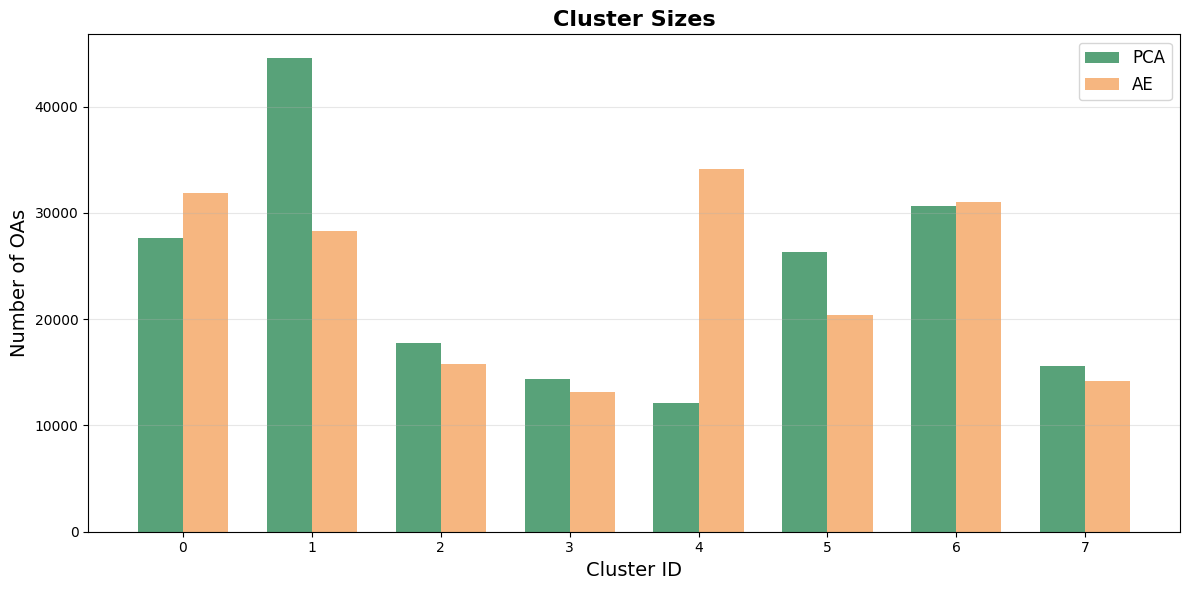

In [18]:
# Cluster size comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_clusters)
width = 0.35

pca_sizes = [np.sum(pca_clusters == i+1) for i in range(n_clusters)]
ae_sizes = [np.sum(ae_clusters == i+1) for i in range(n_clusters)]

ax.bar(x - width/2, pca_sizes, width, label='PCA', color='seagreen', alpha=0.8)
ax.bar(x + width/2, ae_sizes, width, label='AE', color='sandybrown', alpha=0.8)

ax.set_xlabel('Cluster ID', fontsize=14)
ax.set_ylabel('Number of OAs', fontsize=14)
ax.set_title('Cluster Sizes', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{output_dir}/cluster_sizes_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

## Maps

Loading geometries for mapping...
GeoDataFrame: (188880, 4)


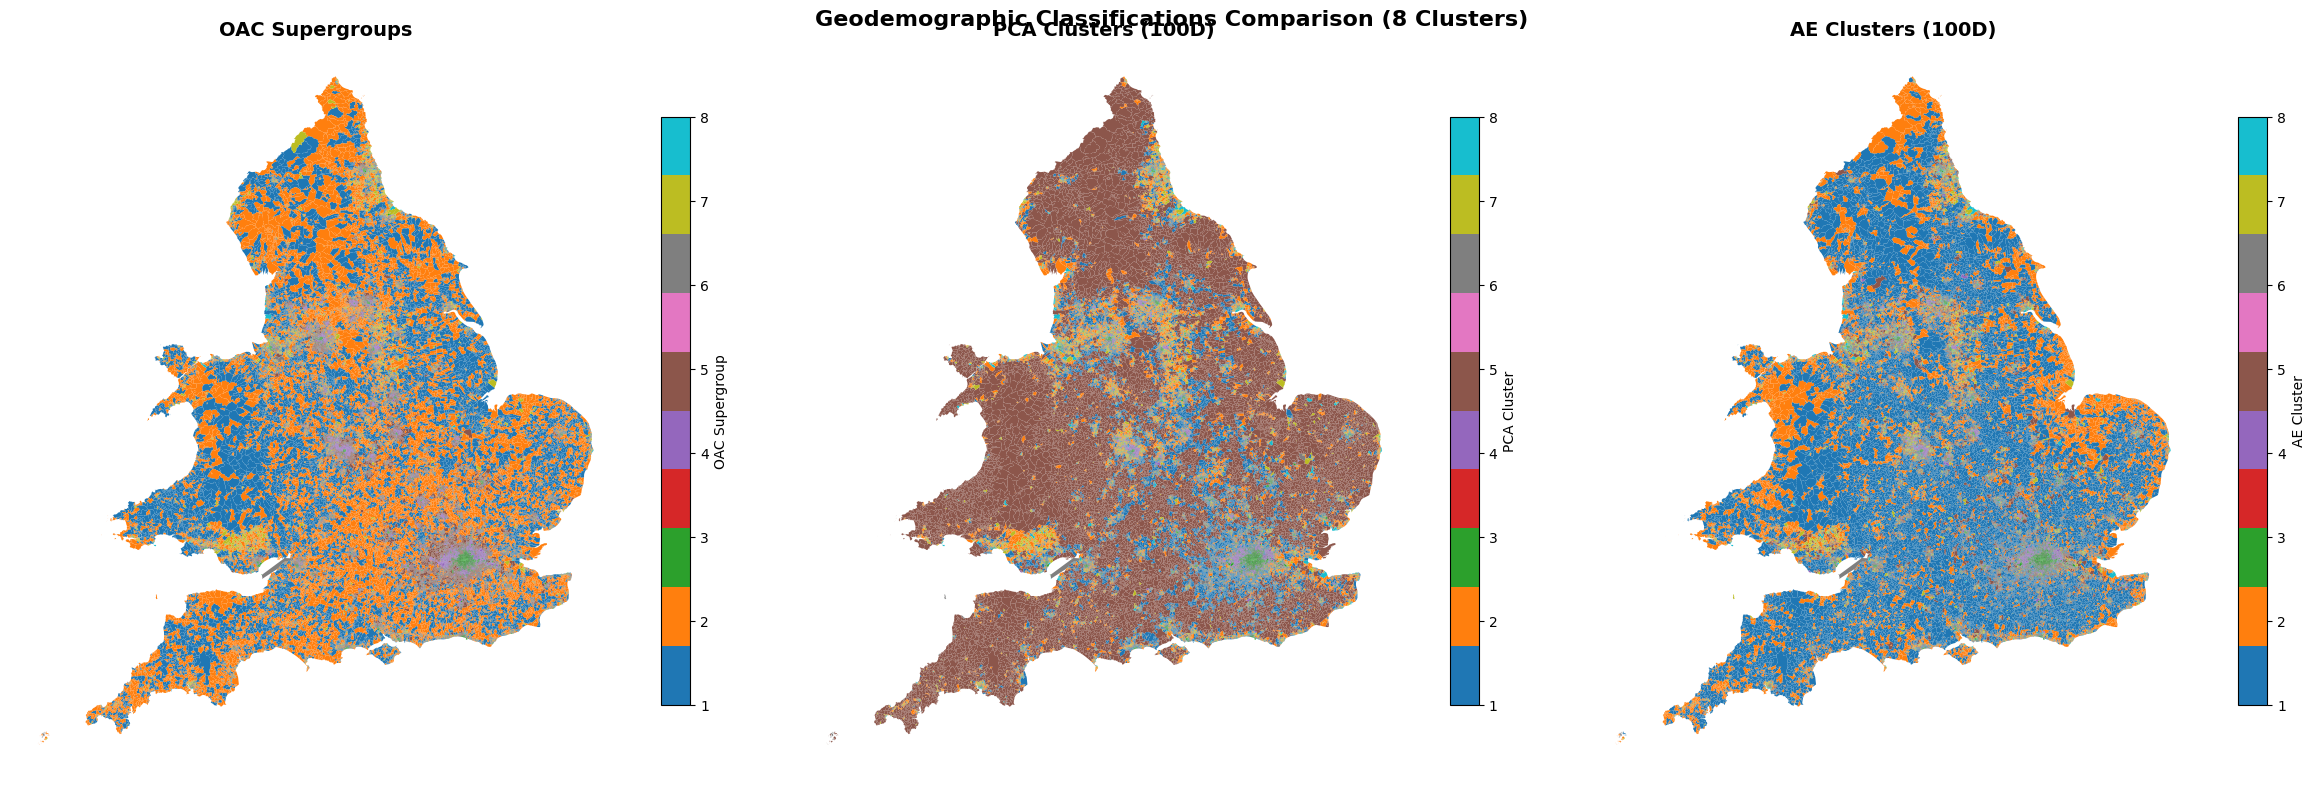

In [19]:
# Load geometries
print("Loading geometries for mapping...")
gdf = gpd.read_file(geo_path)
gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
gdf = gdf.set_index('OA')

# Merge with clusters
gdf = gdf.join(clusters_df)
print(f"GeoDataFrame: {gdf.shape}")

# Create side-by-side maps
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# OAC
gdf.plot(column='oac_supergroup', ax=axes[0], legend=True, 
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'OAC Supergroup', 'shrink': 0.8})
axes[0].set_title('OAC Supergroups', fontsize=14, fontweight='bold')
axes[0].axis('off')

# PCA
gdf.plot(column='pca_cluster', ax=axes[1], legend=True,
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'PCA Cluster', 'shrink': 0.8})
axes[1].set_title(f'PCA Clusters ({target_dim}D)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# AE
gdf.plot(column='ae_cluster', ax=axes[2], legend=True,
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'AE Cluster', 'shrink': 0.8})
axes[2].set_title(f'AE Clusters ({target_dim}D)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.suptitle(f'Geodemographic Classifications Comparison ({n_clusters} Clusters)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(f"{output_dir}/classification_maps_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

Creating regional zoom maps...
London: 29,687 OAs
Cornwall: 1,918 OAs


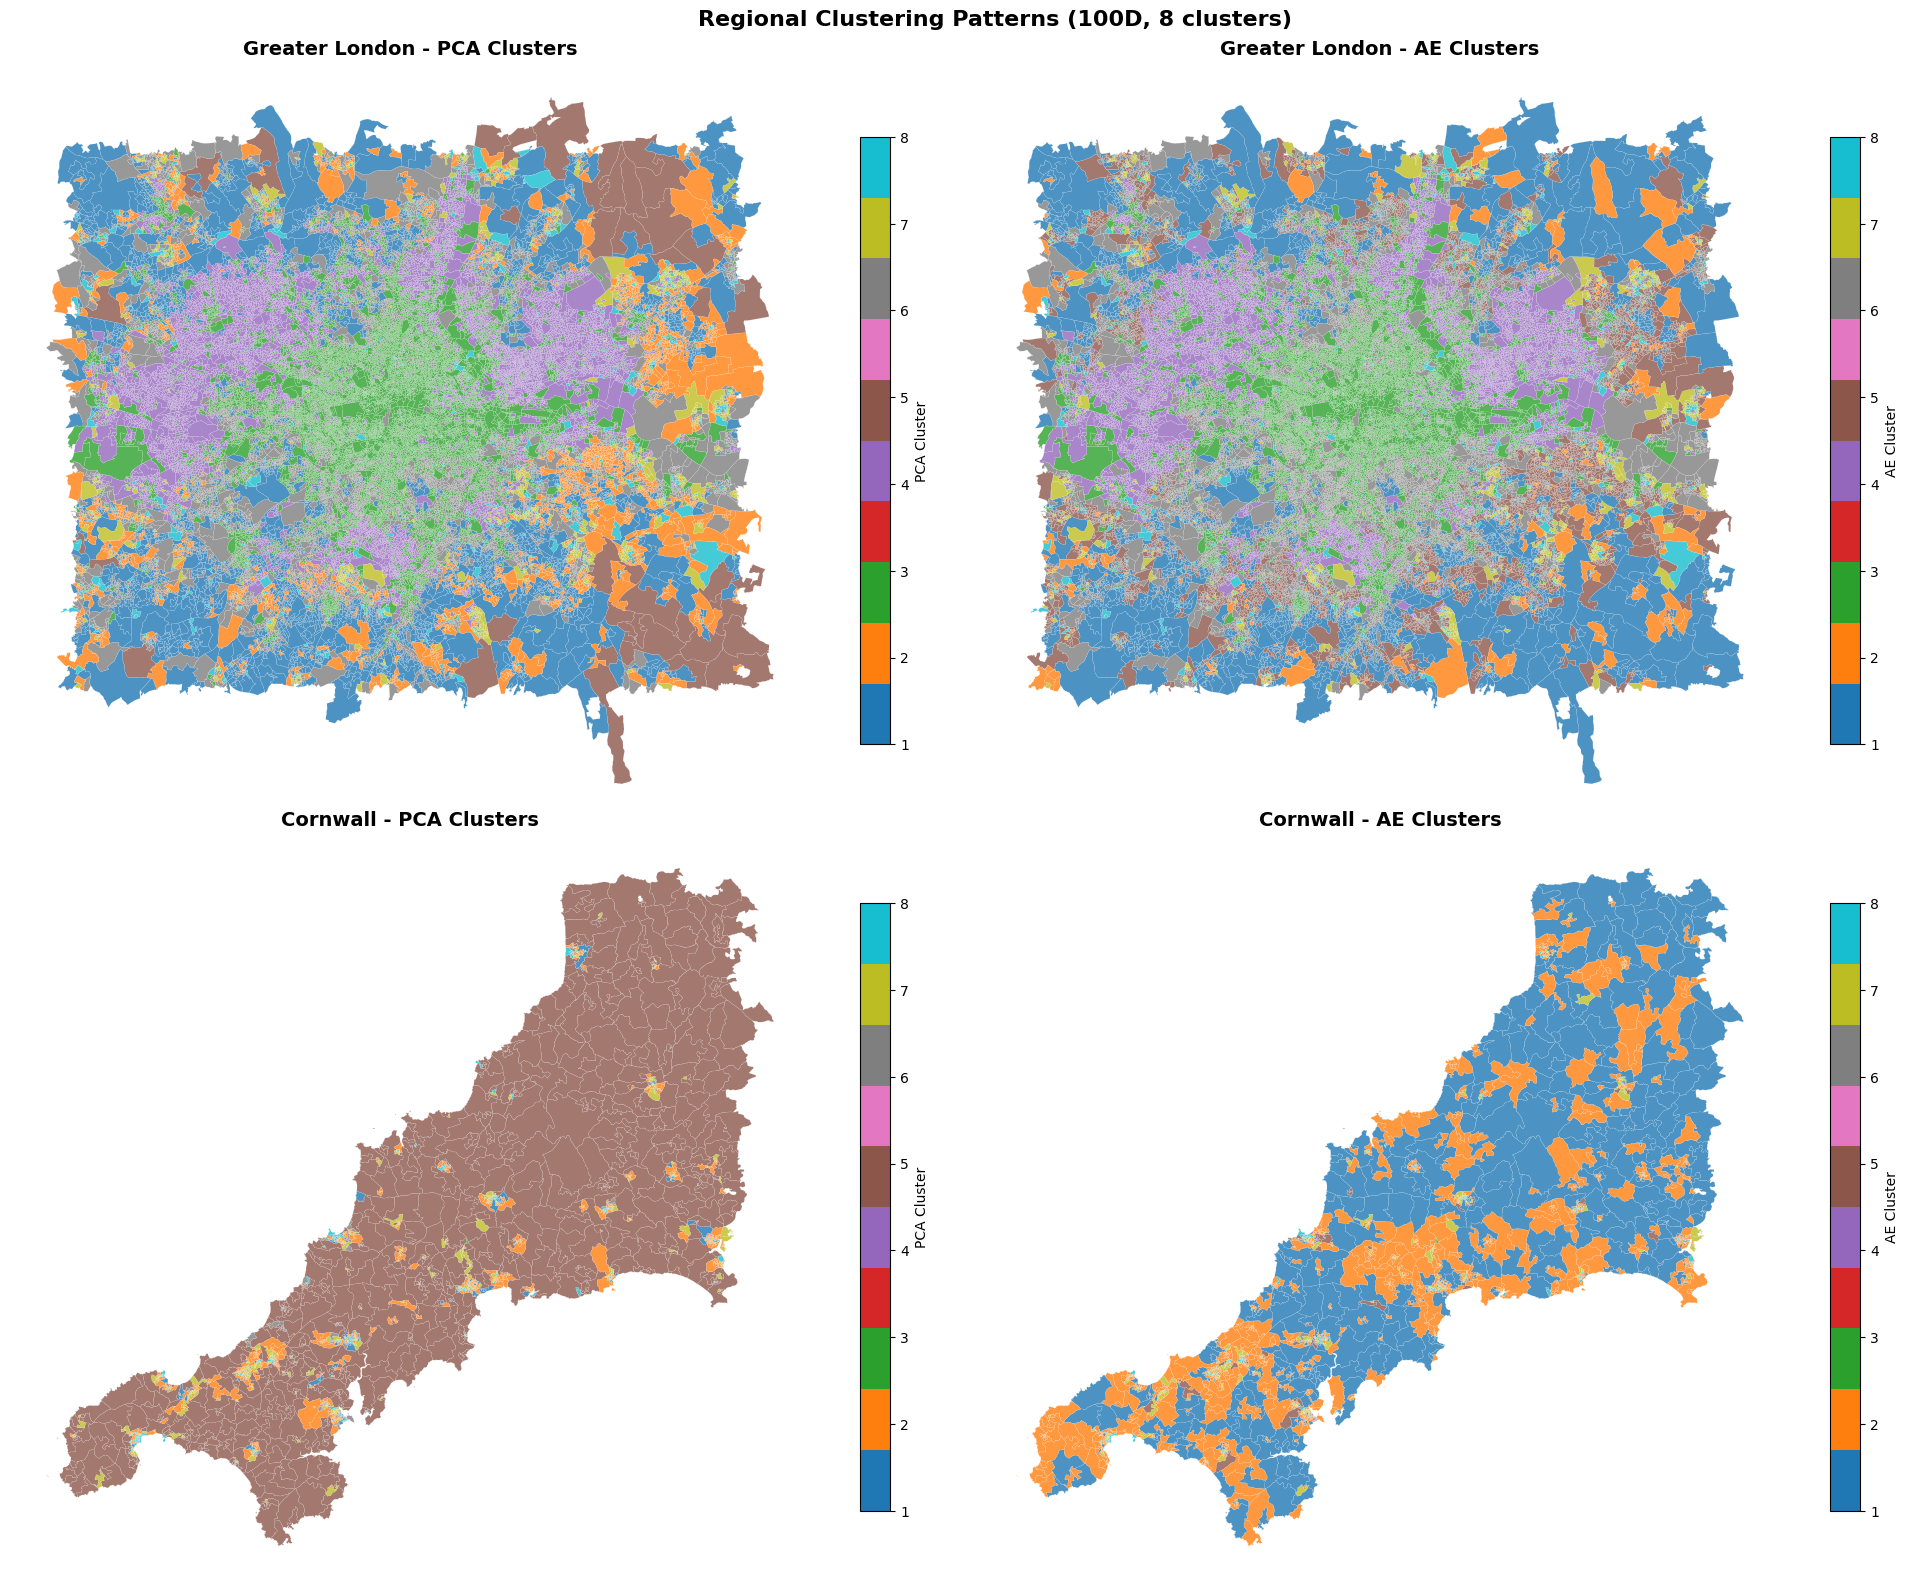


✓ Saved regional maps to ./plots/geodemo_clustering//regional_maps_100d.png


In [20]:
# Regional zoom maps for London and Cornwall
print("Creating regional zoom maps...")

# Define bounding boxes (approximate)
regions = {
    'London': {
        'bounds': {'minx': -0.5, 'maxx': 0.3, 'miny': 51.3, 'maxy': 51.7},
        'title': 'Greater London'
    },
    'Cornwall': {
        'bounds': {'minx': -5.7, 'maxx': -4.2, 'miny': 50.0, 'maxy': 50.9},
        'title': 'Cornwall'
    }
}

# Create figure with 2 rows x 2 columns (London row, Cornwall row)
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

for row_idx, (region_name, region_info) in enumerate(regions.items()):
    # Filter to region using bounding box
    bounds = region_info['bounds']
    region_gdf = gdf.cx[bounds['minx']:bounds['maxx'], bounds['miny']:bounds['maxy']]

    print(f"{region_name}: {len(region_gdf):,} OAs")

    # PCA clusters
    region_gdf.plot(column='pca_cluster', ax=axes[row_idx, 0], legend=True,
                    cmap='tab10', linewidth=0.1, edgecolor='white', alpha=0.8,
                    legend_kwds={'label': 'PCA Cluster', 'shrink': 0.8})
    axes[row_idx, 0].set_title(f'{region_info["title"]} - PCA Clusters',
                                fontsize=14, fontweight='bold')
    axes[row_idx, 0].axis('off')

    # AE clusters
    region_gdf.plot(column='ae_cluster', ax=axes[row_idx, 1], legend=True,
                    cmap='tab10', linewidth=0.1, edgecolor='white', alpha=0.8,
                    legend_kwds={'label': 'AE Cluster', 'shrink': 0.8})
    axes[row_idx, 1].set_title(f'{region_info["title"]} - AE Clusters',
                                fontsize=14, fontweight='bold')
    axes[row_idx, 1].axis('off')

plt.suptitle(f'Regional Clustering Patterns ({target_dim}D, {n_clusters} clusters)',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{output_dir}/regional_maps_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved regional maps to {output_dir}/regional_maps_{target_dim}d.png")

In [22]:
# Export cluster assignments with geometries for QGIS
print("Exporting cluster assignments to parquet for QGIS...")

# Prepare export geodataframe with all relevant columns
export_gdf = gdf[['geometry', 'pca_cluster', 'ae_cluster', 'oac_supergroup']].copy()

# Add cluster names/labels (optional but helpful)
export_gdf['pca_cluster_name'] = 'PCA_' + export_gdf['pca_cluster'].astype(str)
export_gdf['ae_cluster_name'] = 'AE_' + export_gdf['ae_cluster'].astype(str)
export_gdf['oac_name'] = 'OAC_' + export_gdf['oac_supergroup'].astype(str)

# Reset index to include OA code as a column
export_gdf = export_gdf.reset_index()

# Save to parquet (readable by QGIS 3.2+)
export_path = f"{output_dir}/cluster_assignments_with_geometry_{target_dim}d.parquet"
export_gdf.to_parquet(export_path)

print(f"✓ Saved {len(export_gdf):,} OAs to {export_path}")
print(f"\nColumns in export:")
print(f"  - OA: Output Area code")
print(f"  - geometry: Polygon geometry")
print(f"  - pca_cluster: PCA cluster ID (0-{n_clusters-1})")
print(f"  - ae_cluster: AE cluster ID (0-{n_clusters-1})")
print(f"  - oac_supergroup: OAC supergroup (1-8)")
print(f"  - pca_cluster_name: PCA cluster label")
print(f"  - ae_cluster_name: AE cluster label")
print(f"  - oac_name: OAC label")

Exporting cluster assignments to parquet for QGIS...
✓ Saved 188,880 OAs to ./plots/geodemo_clustering//cluster_assignments_with_geometry_100d.parquet

Columns in export:
  - OA: Output Area code
  - geometry: Polygon geometry
  - pca_cluster: PCA cluster ID (0-7)
  - ae_cluster: AE cluster ID (0-7)
  - oac_supergroup: OAC supergroup (1-8)
  - pca_cluster_name: PCA cluster label
  - ae_cluster_name: AE cluster label
  - oac_name: OAC label


## Summary

In [14]:
# Load quality metrics if not in memory
if 'quality_metrics' not in locals():
    data_dir = f"{output_dir}/data/"
    quality_metrics = pd.read_csv(f"{data_dir}/quality_metrics_{target_dim}d.csv")
    wssc_pca = quality_metrics[quality_metrics['Metric'] == 'WSSC/Inertia']['PCA'].values[0]
    wssc_ae = quality_metrics[quality_metrics['Metric'] == 'WSSC/Inertia']['AE'].values[0]
    silhouette_pca = quality_metrics[quality_metrics['Metric'] == 'Silhouette Score']['PCA'].values[0]
    silhouette_ae = quality_metrics[quality_metrics['Metric'] == 'Silhouette Score']['AE'].values[0]
    db_pca = quality_metrics[quality_metrics['Metric'] == 'Davies-Bouldin']['PCA'].values[0]
    db_ae = quality_metrics[quality_metrics['Metric'] == 'Davies-Bouldin']['AE'].values[0]
    print(f"✓ Loaded quality metrics from {data_dir}")

print("="*80)
print(f"GEODEMOGRAPHIC CLUSTERING SUMMARY ({target_dim}D, {n_clusters} clusters)")
print("="*80)

print("\n1. CLUSTER QUALITY METRICS:")
print("-"*80)
print(quality_metrics.to_string(index=False))

print("\n2. COMPARISON TO OAC:")
print("-"*80)
print(f"Adjusted Rand Index:")
print(f"  PCA:  {ari_pca:.4f}")
print(f"  AE:   {ari_ae:.4f}")
print(f"\nV-Measure:")
print(f"  PCA:  {v_pca:.4f}")
print(f"  AE:   {v_ae:.4f}")

print("\n3. CLUSTER SIZES:")
print("-"*80)
size_comparison = pd.DataFrame({
    'Cluster': range(n_clusters),
    'PCA': pca_sizes,
    'AE': ae_sizes
})
print(size_comparison.to_string(index=False))

print("\n" + "="*80)
print(f"All outputs saved to: {output_dir}")
print("="*80)

# Save clusters
clusters_df.to_csv(f"{output_dir}/cluster_assignments_{target_dim}d.csv")

print("\nKey Findings:")
if wssc_ae < wssc_pca:
    print(f"- AE has lower within-cluster variance (WSSC: {wssc_ae:.2f} vs {wssc_pca:.2f})")
else:
    print(f"- PCA has lower within-cluster variance (WSSC: {wssc_pca:.2f} vs {wssc_ae:.2f})")

if silhouette_ae > silhouette_pca:
    print(f"- AE produces better cluster separation (Silhouette: {silhouette_ae:.4f} vs {silhouette_pca:.4f})")
else:
    print(f"- PCA produces better cluster separation (Silhouette: {silhouette_pca:.4f} vs {silhouette_ae:.4f})")

if db_ae < db_pca:
    print(f"- AE clusters are more distinct (Davies-Bouldin: {db_ae:.4f} vs {db_pca:.4f})")
else:
    print(f"- PCA clusters are more distinct (Davies-Bouldin: {db_pca:.4f} vs {db_ae:.4f})")

print(f"\n- Both methods show {'low' if max(ari_pca, ari_ae) < 0.3 else 'moderate'} agreement with OAC")
print("  → Expected: different methods capture different demographic structure")

GEODEMOGRAPHIC CLUSTERING SUMMARY (100D, 8 clusters)

1. CLUSTER QUALITY METRICS:
--------------------------------------------------------------------------------
           Metric           PCA            AE Better Winner
     WSSC/Inertia 219352.044719 172323.098036  Lower     AE
 Silhouette Score      0.124680      0.109896 Higher    PCA
   Davies-Bouldin      1.893196      2.020980  Lower    PCA
Calinski-Harabasz  26125.435624  26030.635571 Higher    PCA

2. COMPARISON TO OAC:
--------------------------------------------------------------------------------
Adjusted Rand Index:
  PCA:  0.2814
  AE:   0.2766

V-Measure:
  PCA:  0.4374
  AE:   0.4318

3. CLUSTER SIZES:
--------------------------------------------------------------------------------
 Cluster   PCA    AE
       0 27647 15795
       1 17725 34135
       2 44570 20401
       3 26305 31060
       4 14335 13131
       5 30640 28254
       6 15561 14201
       7 12097 31903

All outputs saved to: ./plots/geodemo_clustering/
